In [31]:
import pandas as pd
import numpy as np
import wrds

# 3 The international diversification strategy (DIV)

## a) Computing returns of each country in USD

When dowloading the data, wrds gave the monthly data at the end of each month. We thus dowloaded data from fred taking the option "last of the month".

In [32]:
# All those data represent the value of 1 CURRENCY in USD
df_AUS_xchange = pd.read_csv('data/exchange_rates/AUD_to_USD.csv').rename(columns = {'observation_date': 'date', 'DEXUSAL' : 'xchange_rate'})
df_AUS_xchange['date'] = pd.to_datetime(df_AUS_xchange['date']).dt.to_period('M')

df_EU_xchange = pd.read_csv('data/exchange_rates/EU_to_USD.csv').rename(columns = {'observation_date': 'date', 'DEXUSEU' : 'xchange_rate'})
df_EU_xchange['date'] = pd.to_datetime(df_EU_xchange['date']).dt.to_period('M')

df_GBR_xchange = pd.read_csv('data/exchange_rates/UK_to_USD.csv').rename(columns = {'observation_date': 'date', 'DEXUSUK' : 'xchange_rate'})
df_GBR_xchange['date'] = pd.to_datetime(df_GBR_xchange['date']).dt.to_period('M')

df_CHE_xchange = pd.read_csv('data/exchange_rates/USD_to_CHF.csv').rename(columns = {'observation_date': 'date', 'DEXSZUS' : 'xchange_rate'})
df_CHE_xchange['xchange_rate'] =  df_CHE_xchange['xchange_rate'].apply(lambda x: 1/x)
df_CHE_xchange['date'] = pd.to_datetime(df_CHE_xchange['date']).dt.to_period('M')

df_JAP_xchange = pd.read_csv('data/exchange_rates/USD_to_YEN.csv').rename(columns = {'observation_date': 'date', 'DEXJPUS' : 'xchange_rate'})
df_JAP_xchange['xchange_rate'] =  df_JAP_xchange['xchange_rate'].apply(lambda x: 1/x)
df_JAP_xchange['date'] = pd.to_datetime(df_JAP_xchange['date']).dt.to_period('M')

JAP and CHE were given the value of one dolar in the currency, while other currencies were given as the number of dollars required for one unit of the currency. So we need to inverse the value for JAP and CHE in order to be consistent. Also the date of the data from WRDS is given at the end of the month when it is at the end for data from FRED (Even if it the value at the end of the month). So we reformat the date keeping `YYYY-MM` only.

`mportret` are the returns without dividends

In [33]:
df_AUS = pd.read_csv('data/stocks/AUS.csv').drop(columns=['country','currency','mportretx']).rename(columns={'mportret':'local_return'})
df_AUS['date'] = pd.to_datetime(df_AUS['date']).dt.to_period('M')

df_FRA = pd.read_csv('data/stocks/FRA.csv').drop(columns=['country','currency','mportretx']).rename(columns={'mportret':'local_return'})
df_FRA['date'] = pd.to_datetime(df_FRA['date']).dt.to_period('M')

df_DEU = pd.read_csv('data/stocks/DEU.csv').drop(columns=['country','currency','mportretx']).rename(columns={'mportret':'local_return'})
df_DEU['date'] = pd.to_datetime(df_DEU['date']).dt.to_period('M')

df_GBR = pd.read_csv('data/stocks/GBR.csv').drop(columns=['country','currency','mportretx']).rename(columns={'mportret':'local_return'})
df_GBR['date'] = pd.to_datetime(df_GBR['date']).dt.to_period('M')

df_JAP = pd.read_csv('data/stocks/JAP.csv').drop(columns=['country','currency','mportretx']).rename(columns={'mportret':'local_return'})
df_JAP['date'] = pd.to_datetime(df_JAP['date']).dt.to_period('M')

df_CHE = pd.read_csv('data/stocks/CHE.csv').drop(columns=['country','currency','mportretx']).rename(columns={'mportret':'local_return'})
df_CHE['date'] = pd.to_datetime(df_CHE['date']).dt.to_period('M')

df_USA = pd.read_csv('data/stocks/US_Value_Weighted.csv').rename(columns = {'caldt':'date', 'vwretd': 'USA_return'})
df_USA['date'] = pd.to_datetime(df_USA['date']).dt.to_period('M')


### Conversion of local currency returns into USD

The return in local currency is given by:
$$
r^{loc}_{t+1} = \frac{P^{loc}_{t+1} + D^{loc}_{t+1} - P^{loc}_t}{P^{loc}_t} 
$$
Where $P^{loc}_t$ and $D^{loc}_t$ are the price of underlying asset and the dividend paid at time $t$ in the local currency. We denote by $S_t$ the USD value of one unit of the local currency, the return in USD are then given by:
$$
r_{t+1} = \frac{(P^{loc}_{t+1}  + D^{loc}_{t+1})\times S_{t+1} - P^{loc}_t\times S_t}{P^{loc}_t \times S_t} = (r^{loc}_{t+1} + 1)\times\frac{S_{t+1}}{S_{t}} - 1
$$

In [34]:
def compute_ret_in_dollars(df, df_change):
    df = df.merge(df_change, on = 'date', how = 'inner')
    df['dollar_return'] = (df['local_return'] + 1) * (df['xchange_rate'] / df['xchange_rate'].shift(1)) - 1
    return df

df_AUS = compute_ret_in_dollars(df_AUS, df_AUS_xchange)
df_FRA = compute_ret_in_dollars(df_FRA, df_EU_xchange)
df_DEU = compute_ret_in_dollars(df_DEU, df_EU_xchange)
df_CHE = compute_ret_in_dollars(df_CHE, df_CHE_xchange)
df_JAP = compute_ret_in_dollars(df_JAP, df_JAP_xchange)
df_GBR = compute_ret_in_dollars(df_GBR, df_GBR_xchange)
#for USA, no need to compute

## b) Computing unhedged and hedged returns 

$$
X_{t+1}^{EU} = \frac{S_{t+1}}{S_t}(1+r^{EU}) - (1+r^{US})
$$

We have annual interest rates $r_y$, in order to have monthly returns $r_m$:

$$
(1 + r_m)^{12} = (1 + r_{y})  \quad \Leftrightarrow \quad  r_m = (1 + r_{y})^{1/12}  - 1
$$

In [35]:
df_AUS_interest_rate = pd.read_csv('data/interbank_rates/AUS_rates.csv').rename(columns = {'observation_date': 'date', 'IR3TIB01AUM156N' : 'interest_rate'})
df_AUS_interest_rate['date'] = pd.to_datetime(df_AUS_interest_rate['date']).dt.to_period('M')
df_AUS_interest_rate['interest_rate'] /= 100
df_AUS_interest_rate['monthly_ret'] = (1 + df_AUS_interest_rate['interest_rate']) ** (1/12) - 1

df_FRA_interest_rate = pd.read_csv('data/interbank_rates/FRA_rates.csv').rename(columns = {'observation_date': 'date', 'IR3TIB01FRM156N' : 'interest_rate'})
df_FRA_interest_rate['date'] = pd.to_datetime(df_FRA_interest_rate['date']).dt.to_period('M')
df_FRA_interest_rate['interest_rate'] /= 100
df_FRA_interest_rate['monthly_ret'] = (1 + df_FRA_interest_rate['interest_rate']) ** (1/12) - 1

df_DEU_interest_rate = pd.read_csv('data/interbank_rates/DEU_rates.csv').rename(columns = {'observation_date': 'date', 'IR3TIB01DEM156N' : 'interest_rate'})
df_DEU_interest_rate['date'] = pd.to_datetime(df_DEU_interest_rate['date']).dt.to_period('M')
df_DEU_interest_rate['interest_rate'] /= 100
df_DEU_interest_rate['monthly_ret'] = (1 + df_DEU_interest_rate['interest_rate']) ** (1/12) - 1

df_GBR_interest_rate = pd.read_csv('data/interbank_rates/GBR_rates.csv').rename(columns = {'observation_date': 'date', 'IR3TIB01GBM156N' : 'interest_rate'})
df_GBR_interest_rate['date'] = pd.to_datetime(df_GBR_interest_rate['date']).dt.to_period('M')
df_GBR_interest_rate['interest_rate'] /= 100
df_GBR_interest_rate['monthly_ret'] = (1 + df_GBR_interest_rate['interest_rate']) ** (1/12) - 1

df_CHE_interest_rate = pd.read_csv('data/interbank_rates/CHE_rates.csv').rename(columns = {'observation_date': 'date', 'IR3TIB01CHM156N' : 'interest_rate'})
df_CHE_interest_rate['date'] = pd.to_datetime(df_CHE_interest_rate['date']).dt.to_period('M')
df_CHE_interest_rate['interest_rate'] /= 100
df_CHE_interest_rate['monthly_ret'] = (1 + df_CHE_interest_rate['interest_rate']) ** (1/12) - 1

df_JAP_interest_rate = pd.read_csv('data/interbank_rates/JAP_rates.csv').rename(columns = {'observation_date': 'date', 'IR3TIB01JPM156N' : 'interest_rate'})
df_JAP_interest_rate['date'] = pd.to_datetime(df_JAP_interest_rate['date']).dt.to_period('M')
df_JAP_interest_rate['interest_rate'] /= 100
df_JAP_interest_rate['monthly_ret'] = (1 + df_JAP_interest_rate['interest_rate']) ** (1/12) - 1

df_US_interest_rate = pd.read_csv('data/interbank_rates/USA_rates.csv').rename(columns = {'observation_date': 'date', 'IR3TIB01USM156N' : 'interest_rate'})
df_US_interest_rate['date'] = pd.to_datetime(df_US_interest_rate['date']).dt.to_period('M')
df_US_interest_rate['interest_rate'] /= 100
df_US_interest_rate['monthly_ret'] = (1 + df_US_interest_rate['interest_rate']) ** (1/12) - 1

In [36]:
def currency_hedged_returns(df, df_rates, df_loc_rates):
    X = (df['xchange_rate'] / df['xchange_rate'].shift(1))*(1 + df_rates['monthly_ret']) - (1 + df_loc_rates['monthly_ret'])
    df['currency_hedged_ret'] = df['dollar_return'] - X
    return df, pd.concat([X, df['date']], axis = 1).set_index('date')



df_AUS, X_AUS = currency_hedged_returns(df_AUS, df_AUS_interest_rate, df_US_interest_rate)
df_FRA, X_FRA = currency_hedged_returns(df_FRA, df_FRA_interest_rate, df_US_interest_rate)
df_DEU, X_DEU= currency_hedged_returns(df_DEU, df_DEU_interest_rate, df_US_interest_rate)
df_CHE, X_CHE = currency_hedged_returns(df_CHE, df_CHE_interest_rate, df_US_interest_rate)
df_JAP, X_JAP = currency_hedged_returns(df_JAP, df_JAP_interest_rate, df_US_interest_rate)
df_GBR, X_GBR = currency_hedged_returns(df_GBR, df_GBR_interest_rate, df_US_interest_rate)



## c) Portfolios 



In [37]:
risk_free = pd.read_csv('data/risk_free.csv').set_index('date')
risk_free.index = pd.to_datetime(risk_free.index).to_period('M')

In [38]:
DATA_COUNTRIES = [df_AUS, df_FRA, df_DEU, df_CHE, df_JAP, df_GBR]
X_DATA = [X_AUS, X_FRA, X_DEU, X_CHE, X_JAP, X_GBR]
COUNTRIES = ['AUS', 'FRA', 'DEU', 'CHE', 'JAP', 'GBR']

unhedged_ret = df_USA
X_ret = pd.DataFrame(index = df_USA['date'])

for df, x , country in  zip(DATA_COUNTRIES, X_DATA,  COUNTRIES):
    data = df[['date', 'dollar_return']].rename(columns = {'dollar_return':f"{country}_unhedged_return"})
    x.columns = [f"X_{country}"]
    unhedged_ret = pd.merge(unhedged_ret, data, on = 'date', how = 'inner')
    X_ret = pd.merge(X_ret, x, on ='date', how = 'inner').dropna()

unhedged_ret.dropna(inplace=True)
unhedged_ret.set_index('date', inplace=True)


In [39]:
unhedged_ret.head()

,USA_return,AUS_unhedged_return,FRA_unhedged_return,DEU_unhedged_return,CHE_unhedged_return,JAP_unhedged_return,GBR_unhedged_return
date,,,,,,,
2002-02,-0.021700,0.016864,0.003020,-0.001426,0.021465,0.043034,-0.002705
2002-03,0.044698,0.037493,0.059250,0.056479,0.061542,0.063119,0.047827
2002-04,-0.049600,-0.007094,-0.012731,-0.013808,0.032986,0.054354,0.008448
2002-05,-0.010510,0.053397,0.008371,0.010771,0.036389,0.072042,-0.007410
2002-06,-0.070259,-0.032259,-0.029920,-0.017125,-0.034109,-0.051044,-0.043630


In [40]:
hedged_ret = df_USA
for df, country in  zip(DATA_COUNTRIES, COUNTRIES):
    data = df[['date', 'currency_hedged_ret']].rename(columns = {'currency_hedged_ret':f"{country}_hedged_return"})
    hedged_ret = pd.merge(hedged_ret, data, on = 'date', how = 'inner')

hedged_ret.dropna(inplace=True)
hedged_ret.set_index('date', inplace=True)


In [41]:
hedged_ret.head()

,USA_return,AUS_hedged_return,FRA_hedged_return,DEU_hedged_return,CHE_hedged_return,JAP_hedged_return,GBR_hedged_return
date,,,,,,,
2002-02,-0.021700,-0.003951,-0.005698,-0.010145,0.011969,0.043725,-0.005157
2002-03,0.044698,0.003184,0.051212,0.048441,0.049588,0.055126,0.037434
2002-04,-0.049600,-0.016636,-0.046768,-0.047845,-0.003971,0.022735,-0.015600
2002-05,-0.010510,-0.002869,-0.030512,-0.028112,0.003569,0.038684,-0.013437
2002-06,-0.070259,-0.029216,-0.086783,-0.073987,-0.085426,-0.085329,-0.088089


In [42]:
hedged_ret.describe()

,USA_return,AUS_hedged_return,FRA_hedged_return,DEU_hedged_return,CHE_hedged_return,JAP_hedged_return,GBR_hedged_return
count,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000
mean,0.008076,0.006349,0.007036,0.006511,0.006390,0.007282,0.004784
std,0.044372,0.038034,0.046372,0.050201,0.038328,0.046901,0.037740
min,-0.184868,-0.203422,-0.159014,-0.209823,-0.132505,-0.211079,-0.145261
25%,-0.017625,-0.016668,-0.020665,-0.020307,-0.014024,-0.019278,-0.016298
50%,0.012955,0.012540,0.011644,0.011703,0.011227,0.012364,0.010458
75%,0.035247,0.031505,0.035378,0.035908,0.030990,0.038565,0.028810
max,0.126002,0.104856,0.182471,0.171241,0.121576,0.122910,0.126972


In [43]:
from numpy.linalg import inv, LinAlgError

def equally_weighted_portfolio(df,rf, drop_USA = True):
    if drop_USA:
        df = df.drop(columns = [col for col in df.columns if 'USA' in col])
    ret = df.mean(axis = 1)
    mu = ret.mean(axis = 0)
    sigma = ret.std(axis = 0)
    sr = (mu - rf.mean().values[0])/sigma
    return ret, dict({'mean': mu, 'std': sigma, 'sr': sr})



def risk_parity_rolling_portfolio(df, rf, return_weights = False, drop_USA = True):
    if drop_USA:
        df = df.drop(columns = [col for col in df.columns if 'USA' in col])
    rolling_vol = df.rolling(window = 60).std()
    w = 1 / rolling_vol
    w = w.div(w.sum(axis=1), axis=0)
    ret =  (w.shift(1) * df).sum(axis=1)[60:]
    mu = ret.mean(axis = 0)
    sigma = ret.std(axis = 0)
    sr = (mu - rf[60:].mean().values[0])/sigma
    if return_weights:
        return ret, dict({'mean': mu, 'std': sigma, 'sr': sr}), w.shift(1).dropna()
    else: return ret, dict({'mean': mu, 'std': sigma, 'sr': sr})




def get_weights_MV_rolling(df, rf, drop_USA = True):
    if drop_USA:
        df = df.drop(columns = [col for col in df.columns if 'USA' in col])
   
    weights_list = []
    index_list = []
    w_0_list = []

    for t in range(60, len(df)):
        window = df.iloc[t-60:t]
        mu = window.mean().values
        Sigma = window.cov().values
        rf_ = rf.iloc[t-60:t].mean().values[0]
        excess_returns = mu - rf_
        weights = (inv(Sigma) @ excess_returns)/10 # 10 is the risk aversion
        weights_list.append(weights)
        w_0 = 1-sum(weights)
        w_0_list.append(w_0)
        index_list.append(df.index[t])

    w = pd.DataFrame(weights_list, index=index_list, columns=df.columns)
    w_0 = pd.DataFrame(w_0_list, index=index_list)
    w = w.merge(w_0, left_index=True, right_index=True)
    w = w.shift(1)
    return w
  


def get_strategy_returns(df, rf, weights, zero_cost = False, drop_USA = True):
    if drop_USA:
        df = df.drop(columns = [col for col in df.columns if 'USA' in col])
    common_index = df.index.intersection(weights.index)
    df_ = df.loc[common_index]
    weights_ = weights.loc[common_index]
    weights_.columns = df_.columns      #Making sure they have the same columns in order to multiply
    
    strategy_ret = (weights_ * df_).sum(axis=1)
    strategy_ret = strategy_ret.dropna()
    avg_rf = rf.loc[strategy_ret.index].mean().item()
    mu = strategy_ret.mean()
    sigma = strategy_ret.std()
    if zero_cost: sr = mu / sigma
    else:sr = (mu - avg_rf) / sigma
    return strategy_ret, dict({'mean': mu, 'std': sigma, 'sr': sr})




def print_performance(perf):
    print(f"Annualized Mean Return: {100* 12 * perf['mean']:.4f} %")
    print(f"Annualized return volatility {100* np.sqrt(12)*perf['std']:.4f}%")
    print(f"Annualized Sharpe Ratio: {np.sqrt(12)*perf['sr']:.4f}")
    print("\n") 
    

In [44]:
hedged_ret.drop(columns=['USA_return']).mean(axis=1).mean()

np.float64(0.006392007603529142)

In [45]:
ret_EW_hedged, perf_EW_hedged = equally_weighted_portfolio(hedged_ret, risk_free)
ret_EW_unhedged, perf_EW_unhedged = equally_weighted_portfolio(unhedged_ret, risk_free)
print("Equally Weighted Portfolio Hedged")
print_performance(perf_EW_hedged)
print("Equally Weighted Portfolio Unhedged")
print_performance(perf_EW_unhedged)



Equally Weighted Portfolio Hedged
Annualized Mean Return: 7.6704 %
Annualized return volatility 13.0983%
Annualized Sharpe Ratio: 0.4724


Equally Weighted Portfolio Unhedged
Annualized Mean Return: 8.6558 %
Annualized return volatility 16.5836%
Annualized Sharpe Ratio: 0.4326




In [46]:
ret_DIV, perf_RP_hedged = risk_parity_rolling_portfolio(hedged_ret, risk_free)
ret_DIV_unhedged, perf_RP_unhedged = risk_parity_rolling_portfolio(unhedged_ret, risk_free)
print("Risk Parity Portfolio Hedged")
print_performance(perf_RP_hedged)
print("Risk Parity Portfolio Unhedged")
print_performance(perf_RP_unhedged)

Risk Parity Portfolio Hedged
Annualized Mean Return: 6.5275 %
Annualized return volatility 13.1428%
Annualized Sharpe Ratio: 0.4012


Risk Parity Portfolio Unhedged
Annualized Mean Return: 5.7934 %
Annualized return volatility 16.9982%
Annualized Sharpe Ratio: 0.2670




In [47]:
weights_MV_hedged = get_weights_MV_rolling(hedged_ret, risk_free)
weights_MV_unhedged = get_weights_MV_rolling(unhedged_ret, risk_free)
ret_MV_hedged , perf_MV_hedged = get_strategy_returns(hedged_ret.merge(risk_free, right_index=True, left_index=True), risk_free, weights_MV_hedged)
ret_MV_unhedged, perf_MV_unhedged = get_strategy_returns(unhedged_ret.merge(risk_free, right_index=True, left_index=True), risk_free, weights_MV_unhedged)
print("Mean Variance Portfolio Hedged")
print_performance(perf_MV_hedged)
print("Mean Variance Portfolio Unhedged")
print_performance(perf_MV_unhedged)

Mean Variance Portfolio Hedged
Annualized Mean Return: 0.8789 %
Annualized return volatility 17.1911%
Annualized Sharpe Ratio: -0.0188


Mean Variance Portfolio Unhedged
Annualized Mean Return: 2.9948 %
Annualized return volatility 19.2652%
Annualized Sharpe Ratio: 0.0912




In [48]:
unhedged_ret.describe()

,USA_return,AUS_unhedged_return,FRA_unhedged_return,DEU_unhedged_return,CHE_unhedged_return,JAP_unhedged_return,GBR_unhedged_return
count,275.000000,275.000000,275.000000,275.000000,275.000000,275.000000,275.000000
mean,0.008539,0.009333,0.007629,0.007444,0.007735,0.005988,0.005151
std,0.044891,0.062046,0.057228,0.061079,0.045169,0.042308,0.048515
min,-0.184868,-0.286476,-0.215561,-0.308957,-0.147706,-0.136025,-0.197305
25%,-0.017625,-0.022157,-0.028979,-0.025980,-0.016097,-0.018225,-0.019936
50%,0.012955,0.014705,0.010617,0.010771,0.011914,0.006804,0.007972
75%,0.035583,0.044765,0.046005,0.043187,0.037157,0.033281,0.036571
max,0.132193,0.166339,0.207735,0.198042,0.120177,0.151201,0.158189


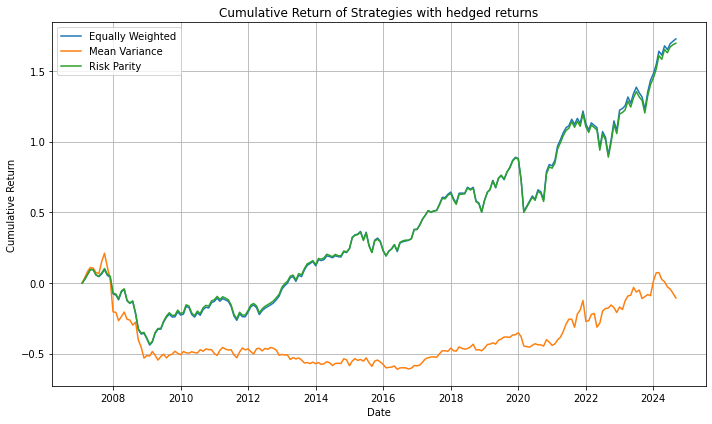

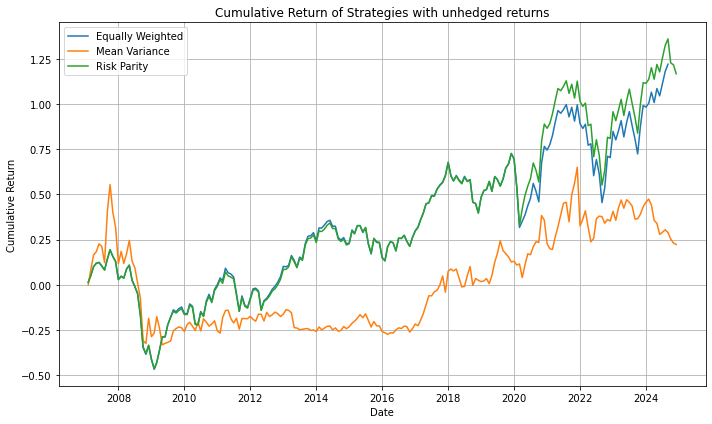

In [49]:
import matplotlib.pyplot as plt

HEDGED = [ret_EW_hedged.loc[ret_DIV.index], ret_MV_hedged, ret_DIV]
UNHEDGED = [ret_EW_unhedged.loc[ret_DIV.index], ret_MV_unhedged, ret_DIV_unhedged]
STRAT = ['Equally Weighted', 'Mean Variance', 'Risk Parity']


plt.figure(figsize=(10, 6))
for ret, strat in zip(HEDGED, STRAT):
    cumret = (1+ ret).cumprod() -1
    cumret.index = cumret.index.to_timestamp()
    plt.plot(cumret, label=strat)
plt.title(f"Cumulative Return of Strategies with hedged returns")
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
for ret, strat in zip(UNHEDGED, STRAT):
    cumret = (1+ ret).cumprod() -1
    cumret.index = cumret.index.to_timestamp()
    plt.plot(cumret, label=strat)
plt.title(f"Cumulative Return of Strategies with unhedged returns")
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# 4. Equity Index Momentum Strategy (MOM)


## a)

In [50]:
def get_momentum_weights(df, window = 12, drop_USA = True):
    if drop_USA:
        df = df.drop(columns = [col for col in df.columns if 'USA' in col])
    cum_ret = df.rolling(window-1).apply(lambda x: ((x + 1).prod() - 1), raw=False)
    ranks = cum_ret.rank(axis=1, ascending=True)
    weights = ranks - (ranks.shape[1] + 1) / 2
    weights = 2 * weights / np.abs(weights).sum(axis=1).values[:, None]
    weights = weights.shift(2) # shift because we want w_t to be cum ret from t-12 to t-1
    weights = weights.dropna()
    return weights


## b)

In [51]:
weights_momentum = get_momentum_weights(hedged_ret, window = 12)
ret_MOM, performance_momentum = get_strategy_returns(hedged_ret, risk_free, weights_momentum, zero_cost=True)
print("Momentum Strategy Hedged")
print_performance(performance_momentum)

Momentum Strategy Hedged
Annualized Mean Return: -2.6729 %
Annualized return volatility 9.0213%
Annualized Sharpe Ratio: -0.2963




In [52]:
hedged_ret.describe()

,USA_return,AUS_hedged_return,FRA_hedged_return,DEU_hedged_return,CHE_hedged_return,JAP_hedged_return,GBR_hedged_return
count,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000
mean,0.008076,0.006349,0.007036,0.006511,0.006390,0.007282,0.004784
std,0.044372,0.038034,0.046372,0.050201,0.038328,0.046901,0.037740
min,-0.184868,-0.203422,-0.159014,-0.209823,-0.132505,-0.211079,-0.145261
25%,-0.017625,-0.016668,-0.020665,-0.020307,-0.014024,-0.019278,-0.016298
50%,0.012955,0.012540,0.011644,0.011703,0.011227,0.012364,0.010458
75%,0.035247,0.031505,0.035378,0.035908,0.030990,0.038565,0.028810
max,0.126002,0.104856,0.182471,0.171241,0.121576,0.122910,0.126972


In [53]:
weights_momentum_long = weights_momentum[weights_momentum > 0].fillna(0)
print(weights_momentum_long.shape)
print(hedged_ret.shape)
ret_long_MOM, performance_momentum_long = get_strategy_returns(hedged_ret, risk_free, weights_momentum_long)
print("Momentum Strategy Hedged Long only")
print_performance(performance_momentum_long)

(259, 6)
(271, 7)
Momentum Strategy Hedged Long only
Annualized Mean Return: 7.3088 %
Annualized return volatility 13.8074%
Annualized Sharpe Ratio: 0.4240




In [54]:
weights_momentum_short = weights_momentum[weights_momentum < 0].fillna(0)
ret_short_MOM, performance_momentum_short = get_strategy_returns(hedged_ret, risk_free, weights_momentum_short)
print("Momentum Strategy Hedged Short only")
print_performance(performance_momentum_short)

Momentum Strategy Hedged Short only
Annualized Mean Return: -9.9817 %
Annualized return volatility 13.2879%
Annualized Sharpe Ratio: -0.8606




In [55]:
import matplotlib.pyplot as plt

def plot_cum_returns(ret, ret_long, ret_short, strategy_name):
    cumret = (1+ ret).cumprod() - 1
    cumret_long = (1 + ret_long).cumprod() - 1
    cumret_short = (1 + ret_short).cumprod() -1


    cumret.index = cumret.index.to_timestamp()
    cumret_long.index = cumret_long.index.to_timestamp()
    cumret_short.index = cumret_short.index.to_timestamp()

    plt.figure(figsize=(10, 6))
    plt.plot(cumret, label=strategy_name)
    plt.plot(cumret_long, label=f"{strategy_name} long only" )
    plt.plot(cumret_short, label=f"{strategy_name} short only")
    plt.title(f"Cumulative Return of {strategy_name} Strategies", fontsize = 18)
    plt.xlabel('Date', fontsize = 16)
    plt.ylabel('Cumulative Return', fontsize = 16)
    plt.legend(fontsize = 16)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

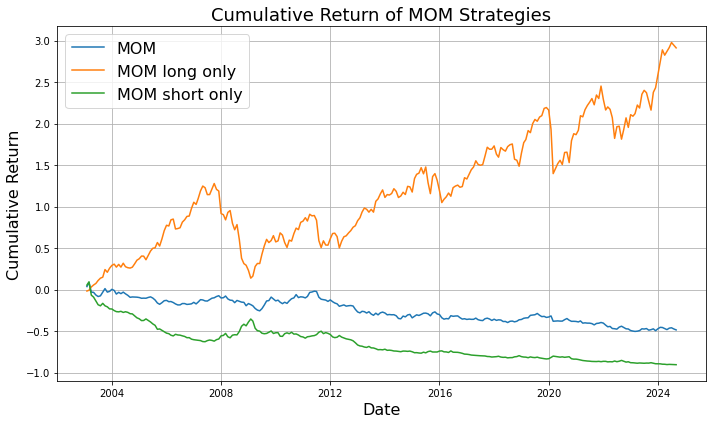

In [56]:
plot_cum_returns(ret_MOM, ret_long_MOM, ret_short_MOM, "MOM")

In [57]:
from scipy.stats import ttest_1samp

t_stat_mom, p_value_mom = ttest_1samp(ret_MOM, 0)
print(f"t-statistic for momentum strategy: {t_stat_mom:.4f}")
print(f"p-value for momentum strategy: {p_value_mom:.4f}")
if p_value_mom < 0.05:
    print("The average return of the MOM strategy is statistically significant at the 5% level.")
else:
    print("The average return of the MOM strategy is not statistically significant at the 5% level.")



t-statistic for momentum strategy: -1.3765
p-value for momentum strategy: 0.1699
The average return of the MOM strategy is not statistically significant at the 5% level.


## c)

In [58]:
import statsmodels.api as sm

data = pd.concat([ret_MOM, ret_DIV], axis=1).dropna()
y = data.iloc[:, 0]
X = sm.add_constant(data.iloc[:, 1])

model = sm.OLS(y, X).fit()
print(model.summary())
         

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     2.866
Date:                Tue, 10 Jun 2025   Prob (F-statistic):             0.0920
Time:                        19:22:49   Log-Likelihood:                 473.69
No. Observations:                 211   AIC:                            -943.4
Df Residuals:                     209   BIC:                            -936.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0025      0.002     -1.372      0.1

$$
R_t^{MOM} = -0.0025 + 0.0793 \times R_t^{DIV} + \varepsilon_t
$$

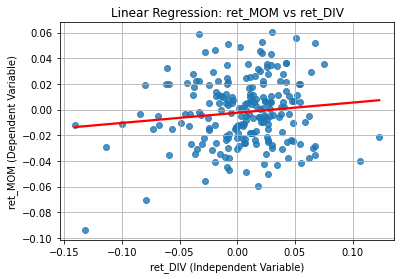

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x= data.iloc[:,1], y= data.iloc[:,0], ci=None, line_kws={"color": "red"})
plt.title("Linear Regression: ret_MOM vs ret_DIV")
plt.xlabel("ret_DIV (Independent Variable)")
plt.ylabel("ret_MOM (Dependent Variable)")
plt.grid(True)
plt.show()




# 5. Equity Index Long Term Reversal startegy (REV)

## a)

In [60]:
def get_reversal_weights(df, lag = 12, window = 60, drop_USA = True):
    if drop_USA:
        df = df.drop(columns = [col for col in df.columns if 'USA' in col])
    cum_ret = df.rolling(window - lag).apply(lambda x: ((x + 1).prod() - 1), raw=False)
    ranks = cum_ret.rank(axis=1, ascending=True)
    weights = (ranks.shape[1] + 1) / 2 - ranks
    weights = 2 * weights / np.abs(weights).sum(axis=1).values[:, None]
    weights = weights.shift(lag+1)
    weights = weights.dropna()
    return weights

## b)

In [61]:
weights_reversal = get_reversal_weights(hedged_ret, lag =12, window = 60)
ret_REV, performance_reversal = get_strategy_returns(hedged_ret, risk_free, weights_reversal, zero_cost=True)
print("Reversal Strategy Hedged")
print_performance(performance_reversal)

Reversal Strategy Hedged
Annualized Mean Return: 0.5850 %
Annualized return volatility 7.5496%
Annualized Sharpe Ratio: 0.0775




In [62]:
weights_reversal_long = weights_reversal[weights_reversal > 0].fillna(0)
ret_REV_long, performance_reversal_long = get_strategy_returns(hedged_ret, risk_free, weights_reversal_long)
print("Reversal Strategy Hedged Long only")
print_performance(performance_reversal_long)

Reversal Strategy Hedged Long only
Annualized Mean Return: 6.5430 %
Annualized return volatility 13.4497%
Annualized Sharpe Ratio: 0.3971




In [63]:
weights_reversal_short = weights_reversal[weights_reversal < 0].fillna(0)
ret_REV_short, performance_reversal_short = get_strategy_returns(hedged_ret, risk_free, weights_reversal_short)
print("Reversal Strategy Hedged Short only")
print_performance(performance_reversal_short)

Reversal Strategy Hedged Short only
Annualized Mean Return: -5.9580 %
Annualized return volatility 14.1688%
Annualized Sharpe Ratio: -0.5053




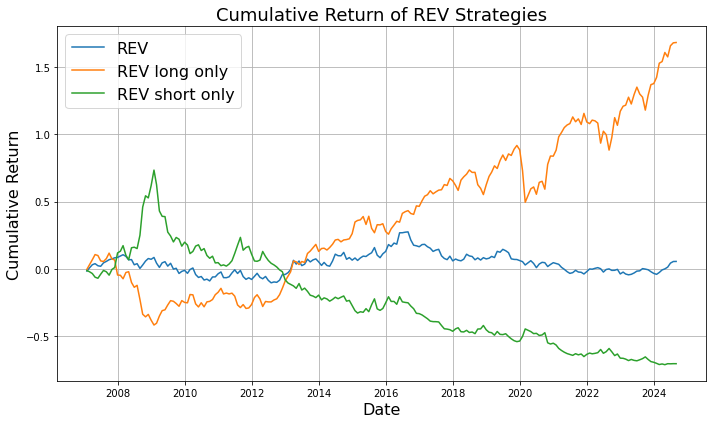

In [64]:
plot_cum_returns(ret_REV, ret_REV_long, ret_REV_short, "REV")

In [65]:
from scipy.stats import ttest_1samp

t_stat_rev, p_value_rev = ttest_1samp(ret_REV, 0)
print(f"t-statistic for reversal strategy: {t_stat_rev:.4f}")
print(f"p-value for reversal strategy: {p_value_rev:.4f}")
if p_value_rev < 0.05:
    print("The average return of the reversal strategy is statistically significant at the 5% level.")
else:
    print("The average return of the reversal strategy is not statistically significant at the 5% level.")

t-statistic for reversal strategy: 0.3249
p-value for reversal strategy: 0.7456
The average return of the reversal strategy is not statistically significant at the 5% level.


## c)

In [66]:
import statsmodels.api as sm

data = pd.concat([ret_REV, ret_DIV], axis=1).dropna()
y = data.iloc[:, 0]
X = sm.add_constant(data.iloc[:, 1])

model2 = sm.OLS(y, X).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     2.970
Date:                Tue, 10 Jun 2025   Prob (F-statistic):             0.0863
Time:                        19:22:50   Log-Likelihood:                 509.91
No. Observations:                 211   AIC:                            -1016.
Df Residuals:                     209   BIC:                            -1009.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.002      0.568      0.5

$$
R_t^{REV} = 0.0009 - 0.068 \times R_t^{DIV} + \varepsilon_t
$$

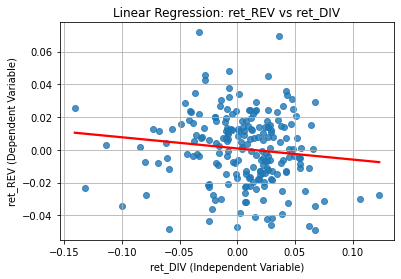

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x= data.iloc[:,1], y= data.iloc[:,0], ci=None, line_kws={"color": "red"})
plt.title("Linear Regression: ret_REV vs ret_DIV")
plt.xlabel("ret_DIV (Independent Variable)")
plt.ylabel("ret_REV (Dependent Variable)")
plt.grid(True)
plt.show()


# 6. Currency Carry Strategy (CARRY)

# a)

In [68]:
# we do not take df_DEU_interest_rate as it is the same as df_FRA_interest_rate
DATA_INTEREST_RATES = [df_AUS_interest_rate, df_FRA_interest_rate, df_CHE_interest_rate, df_JAP_interest_rate, df_GBR_interest_rate]
COUNTRIES = ['AUS', 'FRA', 'CHE', 'JAP', 'GBR']

df_interest_rates = df_US_interest_rate.copy().drop(columns = ['interest_rate']).rename(columns = {'monthly_ret': 'USA_interest_rate'})
for df, country in  zip(DATA_INTEREST_RATES, COUNTRIES):
    data = df[['date', 'monthly_ret']].rename(columns = {'monthly_ret':f"{country}_interest_rate"})
    df_interest_rates = pd.merge(df_interest_rates, data, on = 'date', how = 'inner')
    
df_interest_rates.set_index('date', inplace = True)
df_interest_rates.dropna(inplace = True)


In [69]:
df_interest_rates

,USA_interest_rate,AUS_interest_rate,FRA_interest_rate,CHE_interest_rate,JAP_interest_rate,GBR_interest_rate
date,,,,,,
2002-04,0.001545,0.003747,0.002796,0.001209,0.000083,0.003413
2002-05,0.001504,0.003947,0.002844,0.000964,0.000067,0.003397
2002-06,0.001496,0.004130,0.002842,0.000953,0.000075,0.003416
2002-07,0.001480,0.004058,0.002798,0.000832,0.000075,0.003322
2002-08,0.001430,0.004042,0.002751,0.000555,0.000058,0.003263
...,...,...,...,...,...,...
2024-08,0.004170,0.003579,0.002909,0.000884,0.000212,0.004002
2024-09,0.003962,0.003611,0.002817,0.000848,0.000213,0.003947
2024-10,0.003771,0.003603,0.002601,0.000742,0.000213,0.003875


This is giving the monthly risk free return with the risk free three-months interest rates of each country.

In [70]:
#We are asked to sort by r - r_USA, this is the same as sorting by r

def get_carry_weights(df, drop_USA = True):
    if drop_USA:
        df = df.drop(columns = [col for col in df.columns if 'USA' in col])
    ranks = df.rank(axis=1, ascending=True)
    weights = ranks - (ranks.shape[1] + 1) / 2
    weights = 2 * weights / np.abs(weights).sum(axis=1).values[:, None]
    weights = weights.shift(1) #No need to shift since we are using known rates and not return, but formula in exercise tells us to shift
    weights = weights.dropna()
    return weights

In [71]:
df_interest_rates.drop(columns = ['USA_interest_rate']).rank(axis=1, ascending=False).head(1)

,AUS_interest_rate,FRA_interest_rate,CHE_interest_rate,JAP_interest_rate,GBR_interest_rate
date,,,,,
2002-04,1.0,3.0,4.0,5.0,2.0


Notice that FRA and GER have the same rates, and rank is assigning them a weight of 3.5

In [72]:
X_ret_carry = X_ret.drop(columns=['X_DEU'])


# b)

In [73]:
weights_carry = get_carry_weights(df_interest_rates)
ret_CARRY, performance_carry = get_strategy_returns(X_ret_carry, risk_free, weights_carry, zero_cost=True)
print("Carry Strategy")
print_performance(performance_carry)


Carry Strategy
Annualized Mean Return: 1.5569 %
Annualized return volatility 9.0994%
Annualized Sharpe Ratio: 0.1711




In [74]:
weight_carry_long = weights_carry[weights_carry > 0].fillna(0)
ret_long_CARRY, performance_carry_long = get_strategy_returns(X_ret_carry, risk_free, weight_carry_long)
print("Carry Strategy Long only")
print_performance(performance_carry_long)

Carry Strategy Long only
Annualized Mean Return: 2.2767 %
Annualized return volatility 10.0577%
Annualized Sharpe Ratio: 0.0818




In [75]:
weights_carry_short = weights_carry[weights_carry < 0].fillna(0)
ret_short_CARRY, performance_carry_short = get_strategy_returns(X_ret_carry, risk_free, weights_carry_short)
print("Carry Strategy Short only")
print_performance(performance_carry_short)

Carry Strategy Short only
Annualized Mean Return: -0.7198 %
Annualized return volatility 8.2679%
Annualized Sharpe Ratio: -0.2630




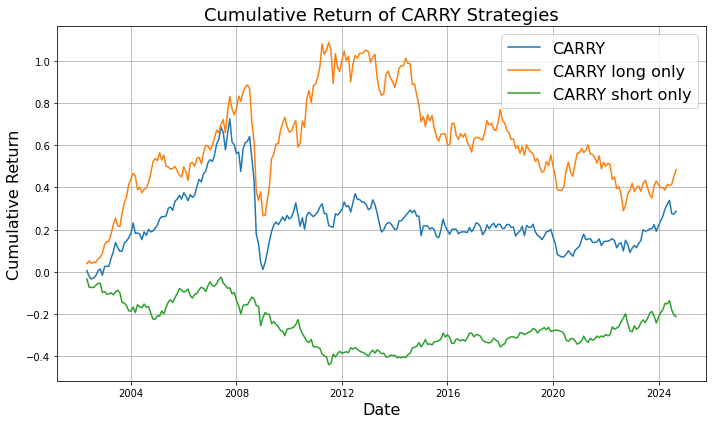

In [76]:
plot_cum_returns(ret_CARRY, ret_long_CARRY, ret_short_CARRY, "CARRY")

In [77]:
from scipy.stats import ttest_1samp
t_stat_carry, p_value_carry = ttest_1samp(ret_CARRY, 0)
print(f"t-statistic for carry strategy: {t_stat_carry:.4f}")
print(f"p-value for carry strategy: {p_value_carry:.4f}")

t-statistic for carry strategy: 0.8086
p-value for carry strategy: 0.4195


# c)

In [78]:
import statsmodels.api as sm
data = pd.concat([ret_CARRY, ret_DIV], axis=1).dropna()
y = data.iloc[:, 0]
X = sm.add_constant(data.iloc[:, 1])
model3 = sm.OLS(y, X).fit()
print(model3.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.285
Model:                            OLS   Adj. R-squared:                  0.282
Method:                 Least Squares   F-statistic:                     83.42
Date:                Tue, 10 Jun 2025   Prob (F-statistic):           5.84e-17
Time:                        19:22:51   Log-Likelihood:                 493.90
No. Observations:                 211   AIC:                            -983.8
Df Residuals:                     209   BIC:                            -977.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0025      0.002     -1.564      0.1

$$
R_t^{CARRY} = -0.0025 + 0.3582 \times R_t^{DIV} + \varepsilon_t
$$

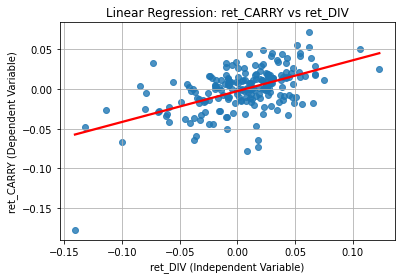

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.regplot(x= data.iloc[:,1], y= data.iloc[:,0], ci=None, line_kws={"color": "red"})
plt.title("Linear Regression: ret_CARRY vs ret_DIV")
plt.xlabel("ret_DIV (Independent Variable)")
plt.ylabel("ret_CARRY (Dependent Variable)")
plt.grid(True)
plt.show()

# 7 Currency dollar Strategy (DOLLAR)

# a)

In [80]:
ret_DOLLAR = -X_ret.mean(axis = 1)

mu = ret_DOLLAR.mean()
sigma = ret_DOLLAR.std()
sr = mu.mean()/ sigma
performance_dollar =  dict({'mean': mu, 'std': sigma, 'sr': sr})

In [81]:
print("Dollar Strategy")
print_performance(performance_dollar)


Dollar Strategy
Annualized Mean Return: -1.1570 %
Annualized return volatility 7.6442%
Annualized Sharpe Ratio: -0.1514




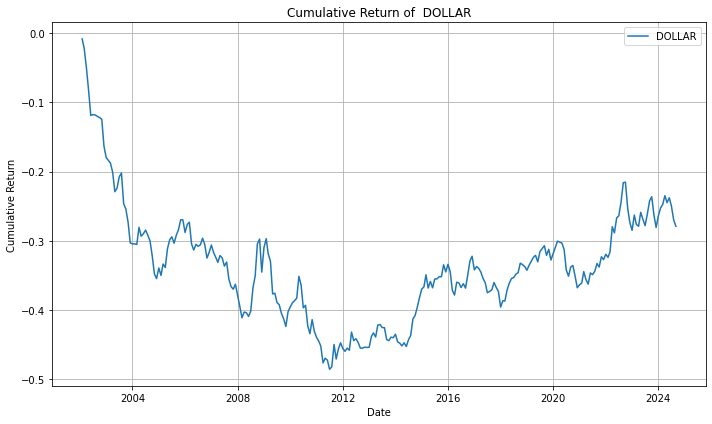

In [82]:
import matplotlib.pyplot as plt



cumret = (1 + ret_DOLLAR).cumprod() - 1
cumret.index = cumret.index.to_timestamp()
plt.figure(figsize=(10, 6))
plt.plot(cumret, label= "DOLLAR")
plt.title(f"Cumulative Return of  DOLLAR")
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# b)

In [83]:
from scipy.stats import ttest_1samp
t_stat_dollar, p_value_dollar = ttest_1samp(ret_DOLLAR, 0)
print(f"t-statistic for carry strategy: {t_stat_dollar:.4f}")
print(f"p-value for carry strategy: {p_value_dollar:.4f}")
if p_value_dollar < 0.05:
    print("The average return of the dollar strategy is statistically significant at the 5% level.")
else:
    print("The average return of the dollar strategy is not statistically significant at the 5% level.")

t-statistic for carry strategy: -0.7193
p-value for carry strategy: 0.4726
The average return of the dollar strategy is not statistically significant at the 5% level.


# c)

In [84]:
import statsmodels.api as sm
data = pd.concat([ret_DOLLAR, ret_DIV], axis=1).dropna()
y = data.iloc[:, 0]
X = sm.add_constant(data.iloc[:, 1])
model4 = sm.OLS(y, X).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     27.04
Date:                Tue, 10 Jun 2025   Prob (F-statistic):           4.75e-07
Time:                        19:22:51   Log-Likelihood:                 516.72
No. Observations:                 211   AIC:                            -1029.
Df Residuals:                     209   BIC:                            -1023.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0015      0.001      1.033      0.3

$$
R_t^{DOLLAR} = - 0.0015 + 0.1986 \times R_t^{DIV} + \varepsilon_t
$$

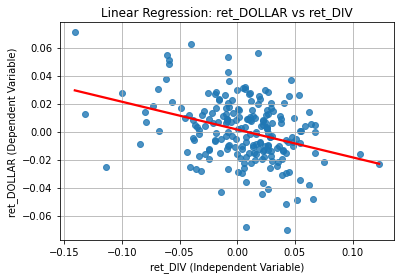

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.regplot(x= data.iloc[:,1], y= data.iloc[:,0], ci=None, line_kws={"color": "red"})
plt.title("Linear Regression: ret_DOLLAR vs ret_DIV")
plt.xlabel("ret_DIV (Independent Variable)")
plt.ylabel("ret_DOLLAR (Dependent Variable)")
plt.grid(True)
plt.show()

# 8 Optimal Fund Portfolio Return (STRAT)

### a)

In [106]:
sigma = 0.15

 Computing vector $a_t$ such that volatility until time t is 0.15, considering that we need at least 5 years of data to have a correct estimate of variance



In [107]:
a_vec = []
ind = []

for t in range(60, len(ret_DIV)):
    var = ret_DIV.iloc[t-60:t-1].var()
    a_vec.append(sigma / np.sqrt(var * 12))
    ind.append(ret_DIV.index[t])
a_vec = pd.Series(a_vec, index=ind)
a_vec = a_vec.dropna()


In [108]:
a_vec.mean()

np.float64(1.271793977321186)

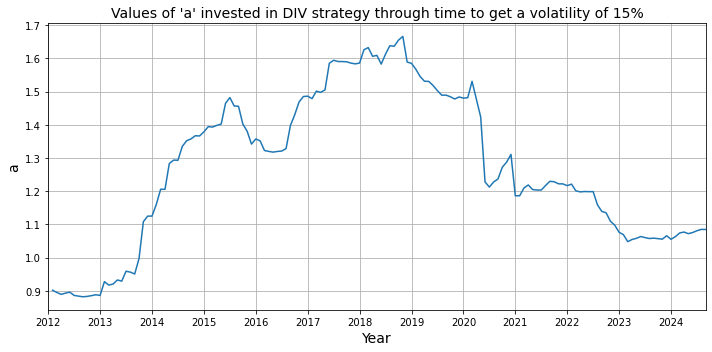

In [109]:
fig, ax = plt.subplots(figsize=(10, 5))
a_vec.plot(ax=ax)

# Format x-axis: show only years
ax.set_xticks([pd.Timestamp(f'{year}-01-01') for year in range(a_vec.index.min().year, a_vec.index.max().year + 1)])
ax.set_xticklabels([str(year) for year in range(a_vec.index.min().year, a_vec.index.max().year + 1)])
ax.set_xlabel("Year", fontsize = 14)
ax.set_ylabel("a", fontsize = 14)
ax.set_title("Values of 'a' invested in DIV strategy through time to get a volatility of 15%", fontsize = 14)
plt.grid(True)
plt.tight_layout()
plt.show()

### b)

In [110]:
df_STRAT = pd.DataFrame({'MOM': ret_MOM, 'REV': ret_REV, 'CARRY': ret_CARRY, 'DOLLAR': ret_DOLLAR}).dropna()
ret_STRAT, perf_STRAT, weights_df= risk_parity_rolling_portfolio(df_STRAT, risk_free.loc[df_STRAT.index], return_weights=True)

print("Risk Parity Strategy on all strategies")
print(f"Annualized Mean Return :  {100*12* ret_STRAT.mean()} %")
print(f"Annualized volatility: : {ret_STRAT.std()*12*100} %")
print(f"Annualized Sharpe Ratio:  {np.sqrt(12)*ret_STRAT.mean()/ret_STRAT.std()}")


Risk Parity Strategy on all strategies
Annualized Mean Return :  0.3146169437144023 %
Annualized volatility: : 13.279219581668755 %
Annualized Sharpe Ratio:  0.08207297546124359


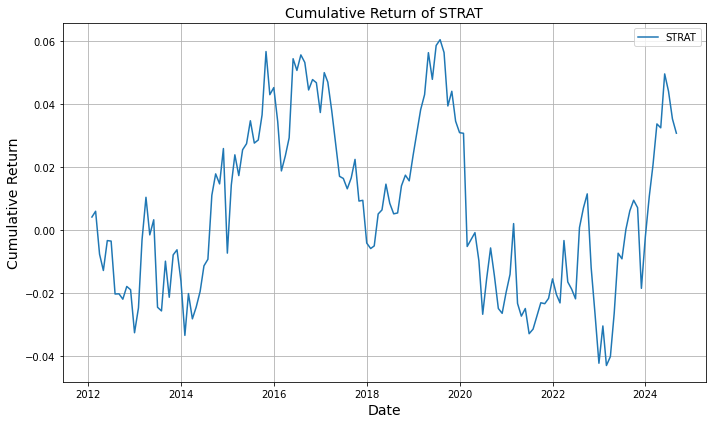

In [111]:
cumret = (1 + ret_STRAT).cumprod() - 1
cumret.index = cumret.index.to_timestamp()
plt.figure(figsize=(10, 6))
plt.plot(cumret, label= "STRAT")
plt.title(f"Cumulative Return of STRAT", fontsize = 14)
plt.xlabel('Date', fontsize = 14)
plt.ylabel('Cumulative Return', fontsize = 14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

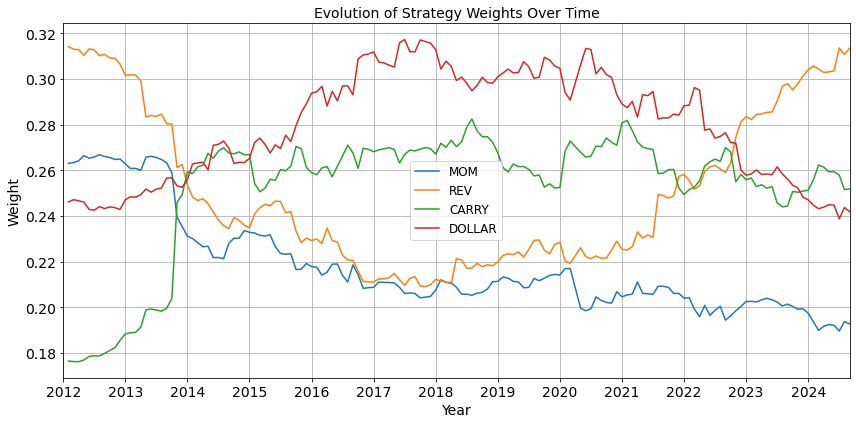

In [112]:

fig, ax = plt.subplots(figsize=(12, 6))
weights_df.plot(ax=ax)


years = range(weights_df.index.min().year, weights_df.index.max().year + 1)
ax.set_xticks([pd.Timestamp(f'{year}-01-01') for year in years])
ax.set_xticklabels([str(year) for year in years], fontsize=14)


ax.set_title("Evolution of Strategy Weights Over Time", fontsize=14)
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Weight", fontsize=14)


ax.tick_params(axis='y', labelsize=14)

plt.grid(True)
plt.tight_layout()
plt.legend(fontsize=12)
plt.show()

### c)

with $\Sigma$ the covariance matrix of $R_{STRAT}$ and $R_{DIV} - R_{T-Bill}$, and $\mu$ the vector of their expected returns we have the follwoing optimization problem:
$$
max_{w}\quad  w^T\mu \quad\quad \text{such that}\quad\quad \sqrt{w^T\Sigma w \times 12} = \sigma\%
$$
or equivalently:
$$
max_{w}\quad  w^T\mu \quad\quad \text{such that}\quad\quad w^T\Sigma w  = \frac{\sigma^2}{12}
$$

The solution is 
$$
w = \frac{\sigma\times\Sigma^{-1}\mu}{\sqrt{12\times\mu^T\Sigma^{-1}\mu}}
$$

# Implementing strategy on rolling windows

We cannot use the mean-variance defined earlier because R_STRAT is a zero cost portfolio

In [113]:
df = pd.DataFrame({'DIV-Tbill':(ret_DIV - risk_free.loc[ret_DIV.index].values.flatten()), 'STRAT':ret_STRAT}).dropna()

weights_list = []
index_list = []

for t in range(60, len(df)):
    window = df.iloc[t-60:t-1]
    mu = window.mean().values
    Sigma = window.cov().values
    

    weights = sigma*inv(Sigma)@mu / np.sqrt(12*mu@inv(Sigma)@mu)
    weights_list.append(weights)
    index_list.append(df.index[t])

w = pd.DataFrame(weights_list, index=index_list, columns = ['b', 'c'])





In [114]:
ret_FUND = (risk_free['r_f'] + w['b'] * (ret_DIV - risk_free['r_f']) + w['c'] * ret_STRAT).dropna()
ret_FUND_a = (risk_free['r_f'] + a_vec * (ret_DIV - risk_free['r_f'])).loc[ret_FUND.index]


In [115]:
def print_performance_fund(ret, risk_free):
    mu = 12*ret.mean()
    sigma = np.sqrt(12)*ret.std()
    sr = (mu - risk_free.loc[ret.index].mean().values[0]) / sigma
    print(f"annualized Mean: {100*mu:.4f}%")
    print(f"annualized Std: {100*sigma:.4f} %")
    print(f"annualized Sharpe Ratio: {sr:.4f}")
    print("\n")

print("FUND strategy performance for R = R_Tbill + a * (R_DIV - R_Tbill)")
print_performance_fund(ret_FUND_a, risk_free)

print("FUND strategy performance for R = R_Tbill + b * (R_DIV - R_Tbill) + c * R_STRAT")
print_performance_fund(ret_FUND, risk_free)

FUND strategy performance for R = R_Tbill + a * (R_DIV - R_Tbill)
annualized Mean: 11.3150%
annualized Std: 16.4705 %
annualized Sharpe Ratio: 0.6767


FUND strategy performance for R = R_Tbill + b * (R_DIV - R_Tbill) + c * R_STRAT
annualized Mean: 9.3516%
annualized Std: 18.2425 %
annualized Sharpe Ratio: 0.5033




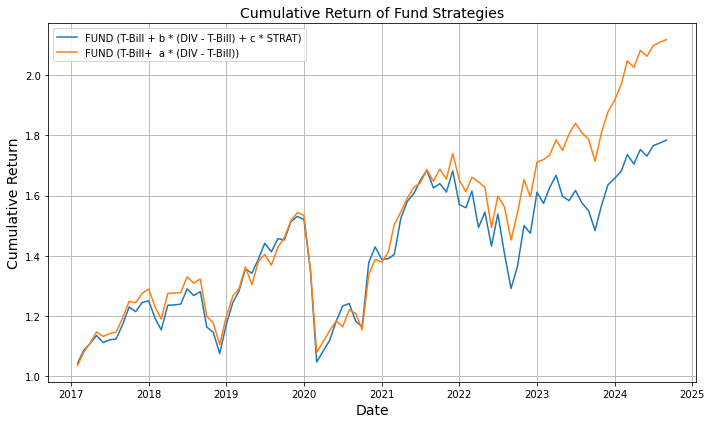

In [116]:
import matplotlib.pyplot as plt

# Compute cumulative returns
cumret_bis = (1 + ret_FUND).cumprod()
cumret_a_bis = (1 + ret_FUND_a).cumprod()

cumret_bis.index = cumret_bis.index.to_timestamp()
cumret_a_bis.index = cumret_a_bis.index.to_timestamp()


plt.figure(figsize=(10, 6))
plt.plot(cumret_bis, label='FUND (T-Bill + b * (DIV - T-Bill) + c * STRAT)')
plt.plot(cumret_a_bis, label='FUND (T-Bill+  a * (DIV - T-Bill))')
plt.title('Cumulative Return of Fund Strategies', fontsize = 14)
plt.xlabel('Date', fontsize = 14)
plt.ylabel('Cumulative Return', fontsize =14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [117]:
print("AVERAGE a = ", a_vec.mean())
print("AVERAGE b = ", w['b'].mean())
print("AVERAGE c = ", w['c'].mean())

AVERAGE a =  1.271793977321186
AVERAGE b =  1.2601609722657
AVERAGE c =  -0.7943077033257882


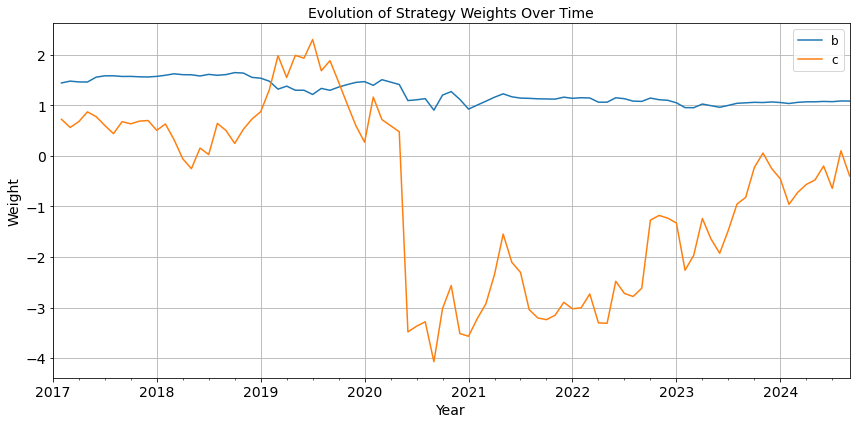

In [118]:
fig, ax = plt.subplots(figsize=(12, 6))
w.plot(ax=ax)


years = range(w.index.min().year, w.index.max().year + 1)
ax.set_xticks([pd.Timestamp(f'{year}-01-01') for year in years])
ax.set_xticklabels([str(year) for year in years], fontsize=14)


ax.set_title("Evolution of Strategy Weights Over Time", fontsize=14)
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Weight", fontsize=14)


ax.tick_params(axis='y', labelsize=14)

plt.grid(True)
plt.tight_layout()
plt.legend(fontsize=12)
plt.show()

In [119]:
weights_FUND = weights_df.mul(w['c'], axis=0).dropna()

In [120]:
weights_FUND['T-Bill'] = 1 - w['b']
weights_FUND['DIV'] = w['b']

In [121]:
weights_FUND.mean()

MOM      -0.158145
REV      -0.209604
CARRY    -0.208810
DOLLAR   -0.217750
T-Bill   -0.260161
DIV       1.260161
dtype: float64

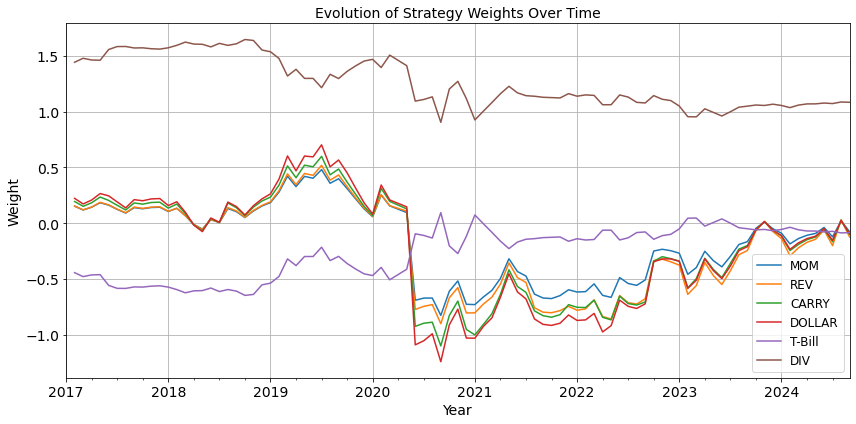

In [122]:
fig, ax = plt.subplots(figsize=(12, 6))
weights_FUND.plot(ax=ax)


years = range(weights_FUND.index.min().year, weights_FUND.index.max().year + 1)
ax.set_xticks([pd.Timestamp(f'{year}-01-01') for year in years])
ax.set_xticklabels([str(year) for year in years], fontsize=14)


ax.set_title("Evolution of Strategy Weights Over Time", fontsize=14)
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Weight", fontsize=14)


ax.tick_params(axis='y', labelsize=14)

plt.grid(True)
plt.tight_layout()
plt.legend(fontsize=12)
plt.show()

# 9. Performance and risk analysis for the Fund strategy

In [123]:
ff5 = pd.read_csv('data/Fama_French_5.csv')
ff5['date'] = pd.to_datetime(ff5['date'], format='%Y%m').dt.to_period('M')
ff5.set_index('date', inplace=True)
ff5 = ff5/100

In [124]:
ff5 = ff5.loc[ret_FUND.index]

In [125]:
import statsmodels.api as sm

data = pd.concat([ret_FUND, ff5], axis=1).dropna()

y = data.iloc[:, 0]  
X = data.iloc[:, 1:]  
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.705
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     33.53
Date:                Tue, 10 Jun 2025   Prob (F-statistic):           2.42e-20
Time:                        19:28:53   Log-Likelihood:                 194.89
No. Observations:                  91   AIC:                            -375.8
Df Residuals:                      84   BIC:                            -358.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0009      0.005     -0.195      0.8